# Heatmap

This section showcases the heatmap. It contains examples of how to create heatmaps using the [datachart.charts.Heatmap](../../../references/charts/#datachart.charts.Heatmap) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-heatmap), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the heatmaps are created using the `Heatmap` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import Heatmap

## Heatmap Input Attributes

The `Heatmap` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the heatmap matrix. For a single heatmap, `data` is a 2D list; a `None` cell is left blank. For multiple heatmaps, `data` is a list of 2D lists.

```python
Heatmap(
    data=List[List[Union[int, float, None]]],          # The heatmap matrix (or list of matrices for multiple charts)
    style={                                             # The style of the heatmap (optional)
        "plot_heatmap_cmap":        Optional[Union[str, List[str]]], # The colormap (palette name or list of hex colors)
        "plot_heatmap_alpha":       Optional[float],    # The alpha of the heatmap (how visible it is)
        "plot_heatmap_font_size":   Optional[Union[int, float, str]], # The font size of the cell values
        "plot_heatmap_font_color":  Optional[str],      # The font color of the cell values (hex color code)
        "plot_heatmap_font_style":  Optional[FONT_STYLE], # The font style of the cell values (normal, italic, etc.)
        "plot_heatmap_font_weight": Optional[FONT_WEIGHT], # The font weight of the cell values (normal, bold, etc.)
        "plot_heatmap_frame_color": Optional[str],      # The color of the frame around the heatmap (hex color code)
    },
    subtitle=Optional[str],                             # The subtitle of the chart (or list for multiple charts)
    title=Optional[str],                                # The title of the chart
    xlabel=Optional[str],                               # The x-axis label
    ylabel=Optional[str],                               # The y-axis label

    figsize=Optional[Tuple[float, float]],              # The figure size in inches
    aspect_ratio=Optional[str],                         # The aspect ratio of the cells ("auto", "equal")
    show_colorbars=Optional[bool],                      # Whether to show the colorbar
    show_heatmap_values=Optional[bool],                 # Whether to write the values into the cells
    valfmt=Optional[str],                               # The format of the cell values (or list for multiple charts)
    colorbar={                                          # The colorbar configuration (or list for multiple charts)
        "orientation": Optional[ORIENTATION],           # The colorbar orientation ("vertical", "horizontal")
    },

    norm=Optional[str],                                 # The value normalization ("linear", "log", "symlog", "asinh", "logit"; or list for multiple charts)
    vmin=Optional[float],                               # The value mapped to the first color (or list for multiple charts)
    vmax=Optional[float],                               # The value mapped to the last color (or list for multiple charts)

    show_grid=Optional[str],                            # Which grid lines to show ("both", "x", "y")
    show_legend=Optional[bool],                         # Whether to show the legend (not typical for heatmaps)
    xmin=Optional[Union[int, float]],                   # The x-axis range (column indices)
    xmax=Optional[Union[int, float]],
    ymin=Optional[Union[int, float]],                   # The y-axis range (row indices)
    ymax=Optional[Union[int, float]],

    max_cols=Optional[int],                             # Maximum number of subplots per row
    sharex=Optional[bool],                              # Whether subplots share the x-axis
    sharey=Optional[bool],                              # Whether subplots share the y-axis

    xticks=Optional[List[Union[int, float]]],           # the x-axis ticks (column indices)
    xticklabels=Optional[List[str]],                    # the x-axis tick labels (must be same length as xticks)
    xtickrotate=Optional[int],                          # the x-axis tick labels rotation
    yticks=Optional[List[Union[int, float]]],           # the y-axis ticks (row indices)
    yticklabels=Optional[List[str]],                    # the y-axis tick labels (must be same length as yticks)
    ytickrotate=Optional[int],                          # the y-axis tick labels rotation
)
```

For more details, see the [datachart.charts.Heatmap](../../../references/charts/#datachart.charts.Heatmap) function.

## Basics

The examples in this guide share one dataset: the monthly climate of six cities. `temperatures` holds the mean air temperature (in °C) and `precipitation` the mean rainfall (in mm) of every month, rounded from the published 1991–2020 climate normals of the cities' weather stations. The data is hard-coded in a hidden cell; each matrix has one row per city, in the order of `CITIES`, and one column per month, in the order of `MONTHS`.

In [2]:
CITIES = ["Reykjavik", "Moscow", "Ljubljana", "Cairo", "Singapore", "Sydney"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# mean monthly temperature in °C, one row per city
temperatures = [
    [-0.2, 0.4, 0.9, 3.2, 6.6, 9.5, 11.3, 10.9, 8.3, 4.9, 1.9, 0.3],
    [-6.5, -6.7, -1.0, 6.7, 13.2, 17.0, 19.2, 17.0, 11.3, 5.6, -1.2, -5.2],
    [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3],
    [14.0, 15.2, 17.9, 21.9, 25.3, 27.8, 28.5, 28.5, 26.8, 24.0, 19.6, 15.5],
    [26.5, 27.1, 27.5, 28.0, 28.3, 28.3, 27.9, 27.9, 27.6, 27.6, 27.0, 26.4],
    [23.0, 22.9, 21.5, 18.8, 15.8, 13.3, 12.5, 13.5, 16.0, 18.2, 20.0, 21.9],
]

# mean monthly precipitation in mm, one row per city
precipitation = [
    [90, 80, 80, 60, 55, 45, 50, 60, 70, 85, 80, 95],
    [50, 40, 35, 40, 50, 80, 85, 80, 65, 70, 55, 50],
    [75, 70, 85, 95, 105, 120, 110, 125, 135, 145, 130, 105],
    [5, 4, 4, 1, 1, 0, 0, 0, 0, 1, 3, 6],
    [240, 160, 185, 180, 170, 130, 150, 175, 170, 190, 260, 290],
    [100, 120, 130, 125, 120, 130, 95, 80, 70, 75, 85, 80],
]

The data is a plain 2D list: each inner list is one row of the heatmap, and each value in it is one cell. The first row is drawn at the top, the first column at the left:

In [3]:
temperatures[:2]

[[-0.2, 0.4, 0.9, 3.2, 6.6, 9.5, 11.3, 10.9, 8.3, 4.9, 1.9, 0.3],
 [-6.5, -6.7, -1.0, 6.7, 13.2, 17.0, 19.2, 17.0, 11.3, 5.6, -1.2, -5.2]]

**Basic example.** Only the `data` argument is required to draw the heatmap. Every cell is colored by its value: the lowest value gets the first color of the colormap, the highest the last.

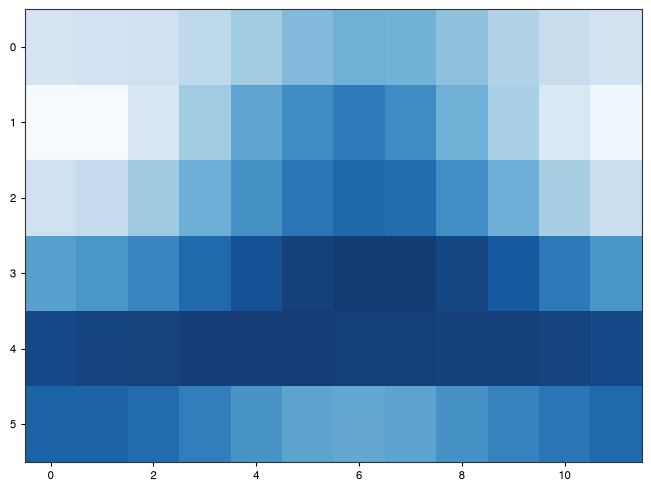

In [4]:
Heatmap(
    # add the data to the chart
    data=temperatures
).show()

## Customizing the Heatmap

Every customization is either a keyword argument of `Heatmap` or a `plot_heatmap_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| name the rows and columns                   | `xticks`, `xticklabels`, `yticks`, `yticklabels`                        | [Ticks and labels](#ticks-and-labels) |
| rotate the tick labels                      | `xtickrotate`, `ytickrotate`                                            | [Ticks and labels](#ticks-and-labels) |
| resize the figure                           | `figsize`                                                               | [Figure size and aspect ratio](#figure-size-and-aspect-ratio) |
| keep the cells square                       | `aspect_ratio`                                                          | [Figure size and aspect ratio](#figure-size-and-aspect-ratio) |
| show the colorbar                           | `show_colorbars`, `colorbar`                                            | [Colorbar and cell values](#colorbar-and-cell-values) |
| write the values into the cells             | `show_heatmap_values`, `valfmt`                                         | [Colorbar and cell values](#colorbar-and-cell-values) |
| change the colormap or transparency         | `style={"plot_heatmap_cmap": ..., "plot_heatmap_alpha": ...}`           | [Heatmap style](#heatmap-style) |
| style the cell values                       | `style={"plot_heatmap_font_size": ..., "plot_heatmap_font_color": ..., ...}` | [Heatmap style](#heatmap-style) |
| change the frame color                      | `style={"plot_heatmap_frame_color": ...}`                               | [Heatmap style](#heatmap-style) |
| fix the value range of the colormap         | `vmin`, `vmax`                                                          | [Normalization](#normalization) |
| spread skewed values over the colormap      | `norm`                                                                  | [Normalization](#normalization) |
| highlight one series, mute the rest         | not supported                                                           | [Emphasis](#emphasis) |
| compare several matrices side by side       | `data` as a list of matrices, `subtitle`                                | [Multiple Heatmap Charts](#multiple-heatmap-charts) |
| arrange the subplots                        | `max_cols`, `sharex`, `sharey`                                          | [Subplot layout and shared axes](#subplot-layout-and-shared-axes) |
| save the chart to a file                    | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.HeatmapStyleAttrs](../../../references/typings/#datachart.typings.HeatmapStyleAttrs) type; the full list of parameters is in the [datachart.charts.Heatmap](../../../references/charts/#datachart.charts.Heatmap) reference.

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes.

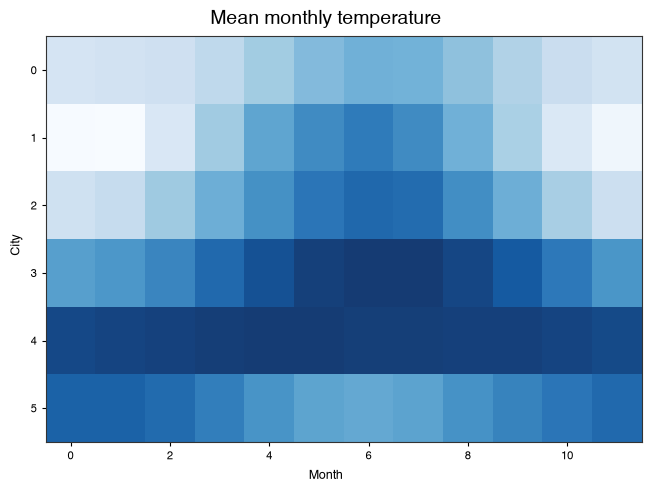

In [5]:
Heatmap(
    data=temperatures,
    # add the title
    title="Mean monthly temperature",
    # add the x and y axis labels
    xlabel="Month",
    ylabel="City",
).show()

### Ticks and labels

A heatmap places column *j* at `x = j` and row *i* at `y = i`, counting from zero, so by default the axes are ticked with cell indices. To name the rows and columns instead, add the `xticks` and `yticks` attributes with the indices to tick and the `xticklabels` and `yticklabels` attributes with their labels — here every column gets its month and every row its city. Tick labels can be rotated with `xtickrotate` and `ytickrotate`.

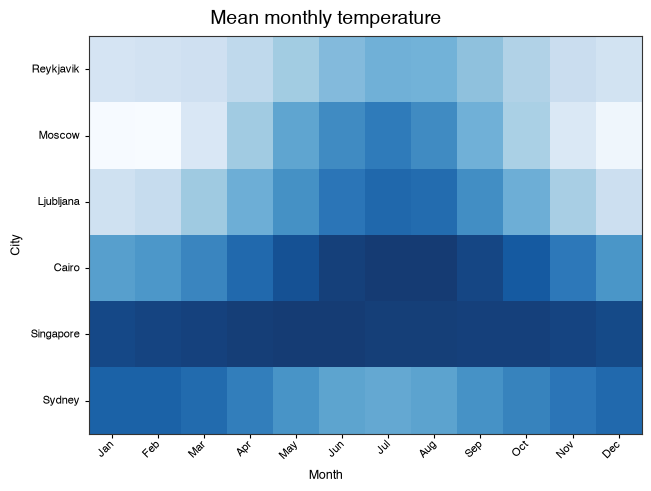

In [6]:
MONTH_TICKS = list(range(len(MONTHS)))
CITY_TICKS = list(range(len(CITIES)))

Heatmap(
    data=temperatures,
    title="Mean monthly temperature",
    xlabel="Month",
    ylabel="City",
    # name the columns and rotate the labels
    xticks=MONTH_TICKS,
    xticklabels=MONTHS,
    xtickrotate=45,
    # name the rows
    yticks=CITY_TICKS,
    yticklabels=CITIES,
).show()

### Figure size and aspect ratio

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains some of the predefined figure sizes.

By default the cells stretch to fill the figure, so their shape follows `figsize`. To keep the cells square whatever the figure size, add the `aspect_ratio` attribute. The possible options are:

| Option | Description |
| --- | --- |
| `"auto"` | the cells stretch to fill the axes (the default). |
| `"equal"` | the cells are square; the axes shrink to fit. |

Again, `datachart` provides a [datachart.constants.ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO) constant, which contains the supported options. A 6 × 12 matrix in a short figure is a natural fit for square cells.

In [7]:
from datachart.constants import FIG_SIZE, ASPECT_RATIO

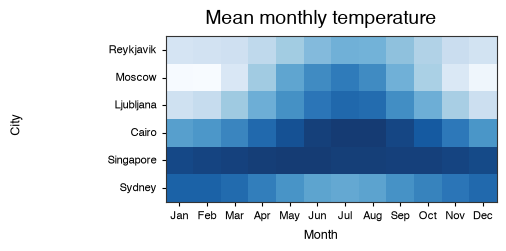

In [8]:
Heatmap(
    data=temperatures,
    title="Mean monthly temperature",
    xlabel="Month",
    ylabel="City",
    xticks=MONTH_TICKS,
    xticklabels=MONTHS,
    yticks=CITY_TICKS,
    yticklabels=CITIES,
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_SHORT,
    # keep the cells square
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Colorbar and cell values

A heatmap on its own shows which cells are higher and which are lower, not by how much. Two attributes add the numbers back: `show_colorbars` draws the colorbar that maps the colors to values, and `show_heatmap_values` writes every value into its cell. On dark cells the value is written in white automatically, so it stays legible across the whole colormap.

The colorbar is vertical and sits to the right of the heatmap; to draw it horizontally, add the `colorbar` attribute with the [datachart.typings.HeatmapColorbarAttrs](../../../references/typings/#datachart.typings.HeatmapColorbarAttrs) typing, whose `orientation` takes a [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) value.

To format the values written into the cells, add the `valfmt` attribute, which is a `string` depicting how to format the values. Examples of such formats are:

| Format | Description |
| --- | --- |
| `"{x}"` | Formats the value as is (no change to the value). |
| `"{x:.0f}"` | Formats the value as an integer (rounds floats). |
| `"{x:.2f}"` | Formats the value as a float with two decimal places. |
| `"{x:.2%}"` | Formats the value as a percentage with two decimal places. |

<div class="admonition note">
    <p class="admonition-title">Required presence of <code>x</code></p>
    <p style="margin-top: .6rem; margin-bottom: .6rem">
        To format the heatmap values, the <code>x</code> value must be present in the string. For instance <code>"{z:.2f}"</code> is not a valid format, and <code>z</code> should be replaced with <code>x</code>.
    </p>
</div>

Again, to help with the settings, the [datachart.constants](../../../references/constants/) module contains the following constants:

| Constant | Description |
| :------- | :---------- |
| [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) | The predefined value formats. |
| [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) | The colorbar orientation. |

The temperatures are given to one decimal place, so the example formats the cells with `VALUE_FORMAT.DECIMAL`.

In [9]:
from datachart.constants import VALUE_FORMAT

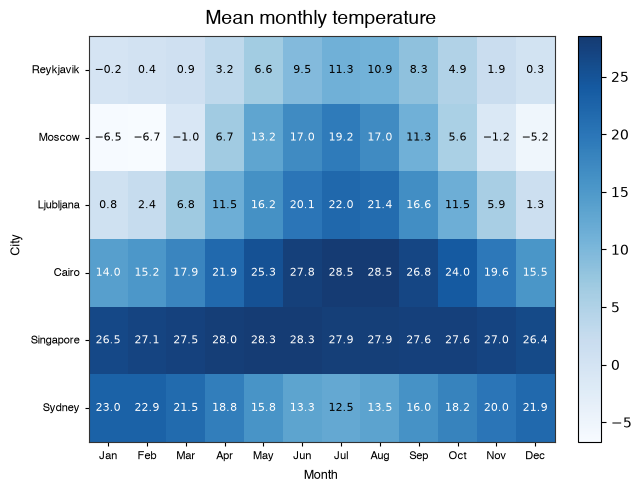

In [10]:
Heatmap(
    data=temperatures,
    title="Mean monthly temperature",
    xlabel="Month",
    ylabel="City",
    xticks=MONTH_TICKS,
    xticklabels=MONTHS,
    yticks=CITY_TICKS,
    yticklabels=CITIES,
    figsize=FIG_SIZE.FULL_MEDIUM,
    # add to show the colorbar
    show_colorbars=True,
    # add to write the values into the cells
    show_heatmap_values=True,
    # format the values with one decimal place
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

### Heatmap style

To change the heatmap style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.HeatmapStyleAttrs](../../../references/typings/#datachart.typings.HeatmapStyleAttrs) type, which contains the following attributes:

| Attribute                     | Description |
| :---------------------------- | :---------- |
| `"plot_heatmap_cmap"`         | The colormap used to draw the heatmap (a palette name or a list of hex colors). |
| `"plot_heatmap_alpha"`        | The alpha of the heatmap (how visible it is).             |
| `"plot_heatmap_font_size"`    | The font size of the cell values.                         |
| `"plot_heatmap_font_color"`   | The font color of the cell values.                        |
| `"plot_heatmap_font_style"`   | The font style of the cell values (normal, italic, etc.). |
| `"plot_heatmap_font_weight"`  | The font weight of the cell values (normal, bold, etc.).  |
| `"plot_heatmap_frame_color"`  | The color of the frame drawn around the heatmap.          |

Again, to help with the style settings, the [datachart.constants](../../../references/constants/) module contains the following constants:

| Constant | Description |
| :------- | :---------- |
| [datachart.constants.COLORS](../../../references/constants/#datachart.constants.COLORS) | The predefined colormaps. |
| [datachart.constants.FONT_STYLE](../../../references/constants/#datachart.constants.FONT_STYLE) | The font style (normal, italic, etc.). |
| [datachart.constants.FONT_WEIGHT](../../../references/constants/#datachart.constants.FONT_WEIGHT) | The font weight (normal, bold, etc.). |

The colormap is the style choice that matters most. Sequential palettes such as `COLORS.Blues` or `COLORS.YlOrRd` run from light to dark and suit values with a natural zero; diverging palettes such as `COLORS.Coolwarm` or `COLORS.RdBu` run through a neutral middle and suit values with a meaningful center. All predefined palettes are rendered in the [Colormaps](../../styling/colormaps/) guide. Any attribute you leave out keeps the value of the active theme.

In [11]:
from datachart.constants import COLORS, FONT_STYLE, FONT_WEIGHT

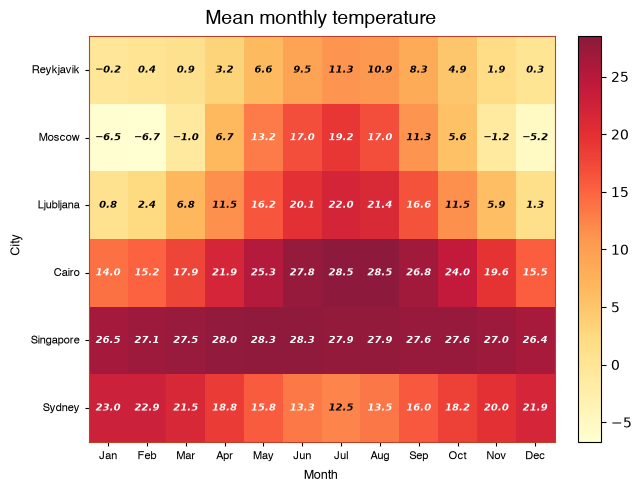

In [12]:
Heatmap(
    data=temperatures,
    # define the style of the heatmap
    style={
        "plot_heatmap_cmap": COLORS.YlOrRd,
        "plot_heatmap_alpha": 0.9,
        "plot_heatmap_font_size": 7,
        "plot_heatmap_font_style": FONT_STYLE.ITALIC,
        "plot_heatmap_font_weight": FONT_WEIGHT.BOLD,
        "plot_heatmap_frame_color": "#b5442c",
    },
    title="Mean monthly temperature",
    xlabel="Month",
    ylabel="City",
    xticks=MONTH_TICKS,
    xticklabels=MONTHS,
    yticks=CITY_TICKS,
    yticklabels=CITIES,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_colorbars=True,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

### Normalization

The colors of a heatmap come from a two-step mapping: the values are first normalized to the 0–1 range, then each normalized value picks its color from the colormap. Both steps can be adjusted.

**Value range.** By default the smallest value in the matrix maps to the first color and the largest to the last. The `vmin` and `vmax` attributes pin those endpoints instead. With a diverging colormap this is what puts the neutral middle color on a meaningful value: the temperatures run from −6.7 to 28.5 °C, so with the default range the white center of `COLORS.Coolwarm` would land on about 11 °C. Pinning the range to −30 … 30 °C places it on the freezing point, and every blue cell is a month below zero.

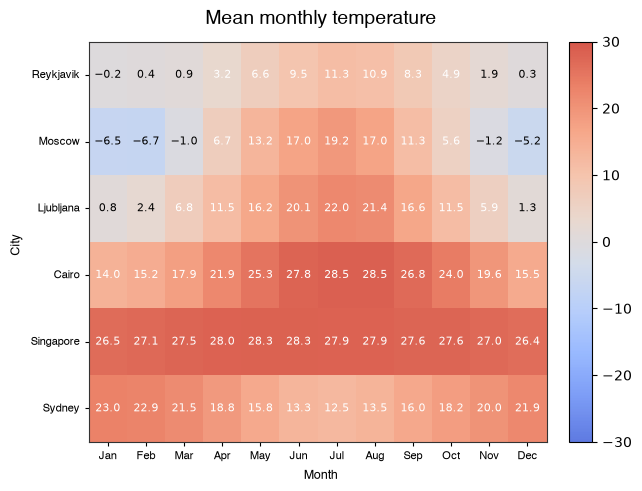

In [13]:
Heatmap(
    data=temperatures,
    style={"plot_heatmap_cmap": COLORS.Coolwarm},
    # pin the value range so that 0 °C sits in the middle of the colormap
    vmin=-30,
    vmax=30,
    title="Mean monthly temperature",
    xlabel="Month",
    ylabel="City",
    xticks=MONTH_TICKS,
    xticklabels=MONTHS,
    yticks=CITY_TICKS,
    yticklabels=CITIES,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_colorbars=True,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

**Normalization.** The `norm` attribute changes how the values are spread over the 0–1 range. The possible options are:

| Option | Description |
| :----- | :---------- |
| `"linear"` | Linear normalization (the default). |
| `"log"` | Log normalization. Non-positive values have no logarithm and are left blank. |
| `"symlog"` | Symmetric log normalization: linear near zero, logarithmic beyond. |
| `"asinh"` | Inverse hyperbolic sine normalization: like `"symlog"`, with a smooth transition. |
| `"logit"` | Logit normalization, for values strictly between 0 and 1. |

Again, `datachart` provides a [datachart.constants.NORMALIZE](../../../references/constants/#datachart.constants.NORMALIZE) constant, which contains the supported options. Note that `norm` is distinct from the `scalex` and `scaley` attributes of the other charts, which scale an axis — here it is the colors that are rescaled.

A non-linear normalization earns its place on skewed data. The `precipitation` matrix runs from Cairo's rain-free summer to Singapore's 290 mm December: on the linear normalization Singapore claims the dark end of the colormap and the seasonal cycles of the other four cities are flattened into pale blues, while the symmetric log normalization spreads the lower values out and the wet and dry seasons of every city show.

In [14]:
from datachart.constants import NORMALIZE

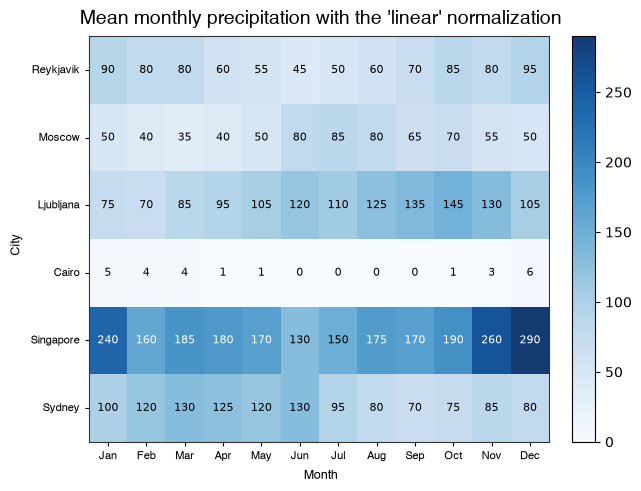

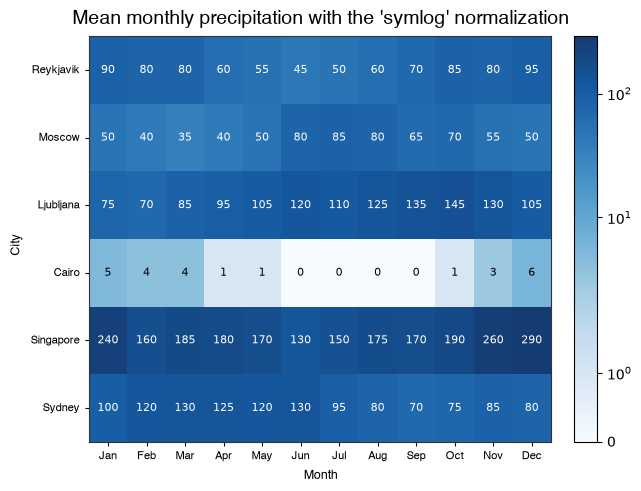

In [15]:
for norm in [NORMALIZE.LINEAR, NORMALIZE.SYMLOG]:
    Heatmap(
        data=precipitation,
        # change how the values are spread over the colormap
        norm=norm,
        title=f"Mean monthly precipitation with the '{norm}' normalization",
        xlabel="Month",
        ylabel="City",
        xticks=MONTH_TICKS,
        xticklabels=MONTHS,
        yticks=CITY_TICKS,
        yticklabels=CITIES,
        figsize=FIG_SIZE.FULL_MEDIUM,
        show_colorbars=True,
        show_heatmap_values=True,
        valfmt=VALUE_FORMAT.INTEGER,
    ).show()

### Emphasis

The other charts accept an `emphasis` attribute that highlights one series and mutes the rest. The heatmap does not: a heatmap is a single raster layer, not a set of series, so there is nothing to bring forward or push back, and `Heatmap` raises a `ValueError` if `emphasis` is passed. To draw attention to part of a heatmap, use the tools above instead — a diverging colormap with a pinned value range, or `vmin` and `vmax` that saturate everything outside the range of interest. See the [Highlighting](../../styling/highlighting/) guide for how emphasis works on the charts that support it.

## Multiple Heatmap Charts

To create multiple heatmaps, pass a list of matrices to the `data` argument. Each matrix is drawn in its own subplot — two rasters cannot share one set of axes — with the `subtitle` at the top of each subplot and the `title`, `xlabel` and `ylabel` positioned to be global for all charts. Per-chart attributes like `subtitle`, `style`, `valfmt`, `norm`, `vmin`, `vmax` and `colorbar` can be passed as lists, where each element corresponds to a chart; a single value applies to every chart.

<div class="admonition note">
    <p class="admonition-title">Multiple charts pattern</p>
    <p style="margin-top: .6rem; margin-bottom: .6rem">
        For multiple charts, <code>data</code> becomes a list of matrices, and per-chart attributes like <code>subtitle</code>, <code>style</code> and <code>valfmt</code> become lists where each element applies to the corresponding chart.
    </p>
</div>

The example draws the temperatures and the precipitation of the six cities side by side. The two matrices hold different quantities, so each gets its own subtitle and its own colormap through a list of `style` dictionaries (`None` keeps the theme style for that chart). Twelve columns side by side leave no room for the cell values; the next section stacks the charts and writes them in.

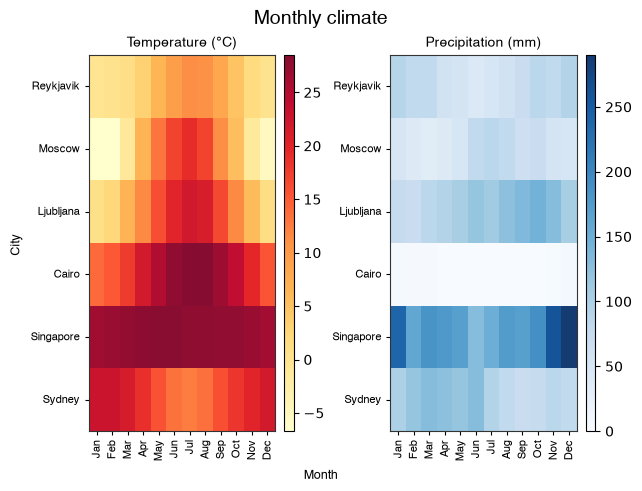

In [16]:
Heatmap(
    # use a list of matrices to define multiple heatmaps
    data=[temperatures, precipitation],
    # add a subtitle to each chart
    subtitle=["Temperature (°C)", "Precipitation (mm)"],
    # style can be a list (one per chart) or a single dict (applies to all)
    style=[
        {"plot_heatmap_cmap": COLORS.YlOrRd},
        None,  # keep the theme style for the second chart
    ],
    title="Monthly climate",
    xlabel="Month",
    ylabel="City",
    xticks=MONTH_TICKS,
    xticklabels=MONTHS,
    xtickrotate=90,
    yticks=CITY_TICKS,
    yticklabels=CITIES,
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_colorbars=True,
).show()

### Subplot layout and shared axes

The `max_cols` attribute limits the number of subplots per row — with `max_cols=1` the charts stack vertically, which gives a wide matrix the full figure width and room for the cell values. Like `style`, `valfmt` can be a list with one format per chart: the temperatures keep their decimal place, the precipitation is written as integers. To share the x-axis and/or y-axis across subplots, add the `sharex` and/or `sharey` attributes, which are boolean values that specify whether to share the axis across all subplots; a shared axis is labeled once, on the outer subplots only.

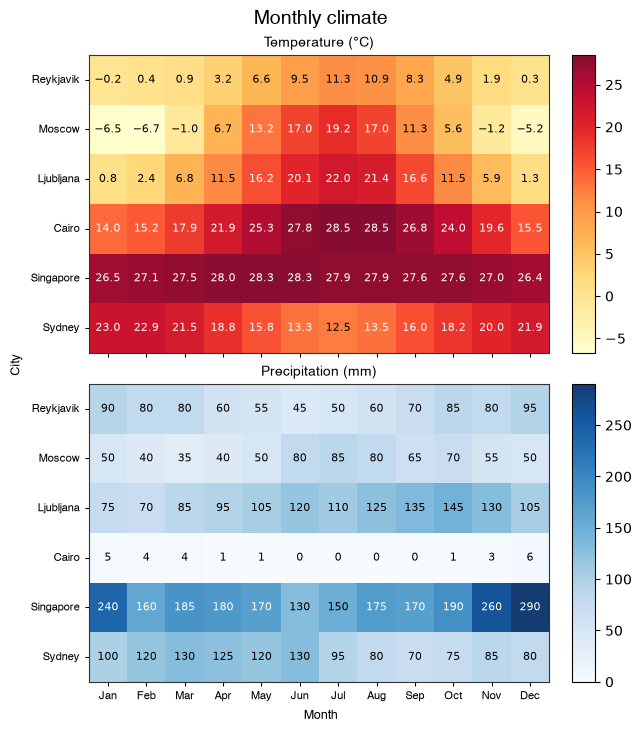

In [17]:
figure = Heatmap(
    data=[temperatures, precipitation],
    subtitle=["Temperature (°C)", "Precipitation (mm)"],
    style=[
        {"plot_heatmap_cmap": COLORS.YlOrRd},
        None,
    ],
    # format the values of each chart on its own
    valfmt=[VALUE_FORMAT.DECIMAL, VALUE_FORMAT.INTEGER],
    title="Monthly climate",
    xlabel="Month",
    ylabel="City",
    xticks=MONTH_TICKS,
    xticklabels=MONTHS,
    yticks=CITY_TICKS,
    yticklabels=CITIES,
    figsize=FIG_SIZE.FULL_TALL,
    show_colorbars=True,
    show_heatmap_values=True,
    # stack the charts in one column
    max_cols=1,
    # share the x-axis across subplots
    sharex=True,
)
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [18]:
from datachart.utils import save_figure

In [19]:
save_figure(figure, "./fig_heatmap.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work on real or realistic data. Each one states what its data is and where it comes from; the data itself lives in a hidden cell.

### Example 1: Correlation Matrix (Diverging Colormap and Pinned Value Range)

`correlations` holds the Pearson correlation between the four body measurements — bill length, bill depth, flipper length and body mass — of the 342 penguins of the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0). A correlation matrix is the textbook case for a diverging colormap: the sign matters as much as the size, so `COLORS.Coolwarm` is pinned to the −1 … 1 range with `vmin` and `vmax`, which puts white on zero and the same shade on equal correlations of either sign. The variable names label both axes, `VALUE_FORMAT.DECIMAL_2` writes the coefficients into the cells, and `ASPECT_RATIO.EQUAL` keeps the matrix square.

In [20]:
VARIABLES = ["Bill length", "Bill depth", "Flipper length", "Body mass"]

# Pearson correlation between the body measurements of the Palmer penguins
correlations = [
    [1.00, -0.24, 0.66, 0.60],
    [-0.24, 1.00, -0.58, -0.47],
    [0.66, -0.58, 1.00, 0.87],
    [0.60, -0.47, 0.87, 1.00],
]

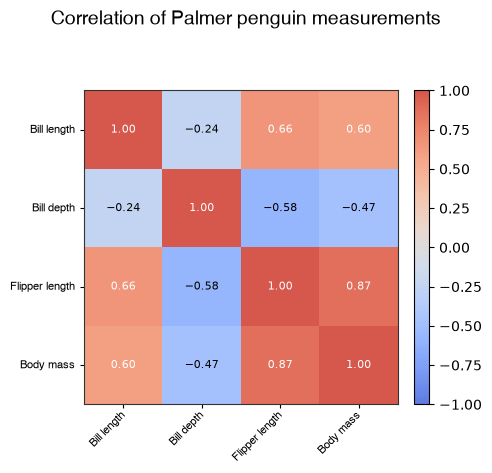

In [21]:
VARIABLE_TICKS = list(range(len(VARIABLES)))

Heatmap(
    data=correlations,
    # a diverging colormap, pinned so that zero sits on white
    style={"plot_heatmap_cmap": COLORS.Coolwarm},
    vmin=-1,
    vmax=1,
    title="Correlation of Palmer penguin measurements",
    # name the variables on both axes
    xticks=VARIABLE_TICKS,
    xticklabels=VARIABLES,
    xtickrotate=45,
    yticks=VARIABLE_TICKS,
    yticklabels=VARIABLES,
    figsize=FIG_SIZE.SQUARE,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    show_colorbars=True,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL_2,
).show()

### Example 2: Confusion Matrix (Integer Cell Values and Class Labels)

`confusion` holds the illustrative confusion matrix of a topic classifier evaluated on 1,000 news articles, 250 in each of four topics: each row is the true topic, each column the predicted one, and each cell the number of articles. The diagonal holds the correct predictions; the off-diagonal cells show which topics get mixed up — here business and politics articles for one another. The class names label both axes, `VALUE_FORMAT.INTEGER` writes the counts into the cells, and the sequential default colormap makes the diagonal stand out. The colorbar is left out — the cell values already carry the numbers.

In [22]:
TOPICS = ["Business", "Politics", "Science", "Sports"]

# rows: true topic, columns: predicted topic, cells: number of articles
confusion = [
    [218, 21, 9, 2],
    [27, 209, 6, 8],
    [14, 5, 226, 5],
    [3, 6, 4, 237],
]

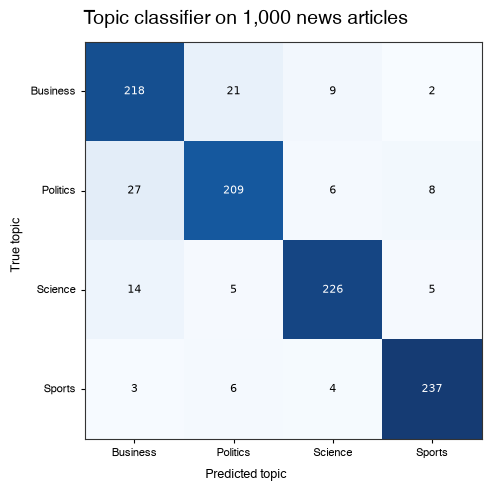

In [23]:
TOPIC_TICKS = list(range(len(TOPICS)))

Heatmap(
    data=confusion,
    title="Topic classifier on 1,000 news articles",
    xlabel="Predicted topic",
    ylabel="True topic",
    # name the classes on both axes
    xticks=TOPIC_TICKS,
    xticklabels=TOPICS,
    yticks=TOPIC_TICKS,
    yticklabels=TOPICS,
    figsize=FIG_SIZE.SQUARE,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    # write the counts into the cells
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.INTEGER,
).show()

### Example 3: Contributions Calendar (Blank Cells, Sparse Ticks and Skewed Counts)

`contributions` holds the number of commits on each day of 2025 by one illustrative developer, drawn from a seeded generator: most weekdays see a few commits, weekends rarely any, and two release weeks in March and September see a burst of them. The matrix is laid out like the GitHub contributions graph — one row per weekday from Monday to Sunday, one column per week of the year — and the days before January 1 and after December 31 in the first and last week are `None`, so they are left blank. The calendar only makes sense with square cells (`ASPECT_RATIO.EQUAL`) and a wide, short figure; `yticks` label every other weekday, `xticks` mark the week each month starts in (`month_weeks`, computed in the hidden cell), and the colormap is GitHub's green scale passed as a list of hex colors. The release weeks would drown the everyday commits on a linear colormap, so `NORMALIZE.ASINH` spreads the low counts over the greens. There is no colorbar: the calendar is read by pattern, not by value.

In [24]:
import datetime
import numpy as np

rng = np.random.RandomState(3)
YEAR = 2025

first_day = datetime.date(YEAR, 1, 1)
n_days = (datetime.date(YEAR + 1, 1, 1) - first_day).days
# week index of the first day; January 1 may fall mid-week
offset = first_day.weekday()
n_weeks = (offset + n_days + 6) // 7

# rows: Monday to Sunday, columns: weeks; days outside the year stay None
contributions = [[None] * n_weeks for _ in range(7)]
month_weeks = []
for i in range(n_days):
    day = first_day + datetime.timedelta(days=i)
    week = (offset + i) // 7
    weekday = day.weekday()
    if weekday < 5:
        commits = int(rng.poisson(2.5)) if rng.rand() < 0.7 else 0
        # release weeks in March and September
        if day.isocalendar()[1] in (11, 37):
            commits += int(rng.poisson(12))
    else:
        commits = int(rng.poisson(0.8)) if rng.rand() < 0.3 else 0
    contributions[weekday][week] = commits
    if day.day == 1:
        month_weeks.append(week)

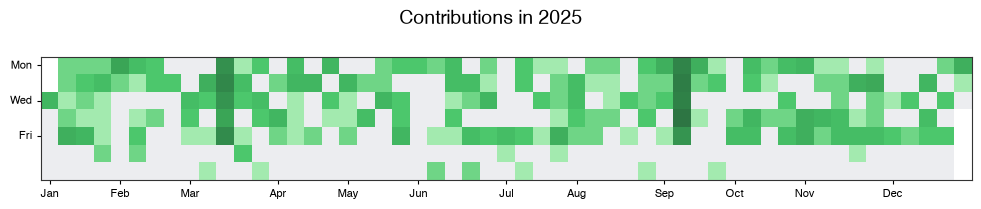

In [25]:
# the green scale of the GitHub contributions graph, from no commits to many
GITHUB_GREENS = ["#ebedf0", "#9be9a8", "#40c463", "#30a14e", "#216e39"]

Heatmap(
    data=contributions,
    style={"plot_heatmap_cmap": GITHUB_GREENS},
    # spread the everyday counts over the colormap despite the release weeks
    norm=NORMALIZE.ASINH,
    title=f"Contributions in {YEAR}",
    # label every other weekday
    yticks=[0, 2, 4],
    yticklabels=["Mon", "Wed", "Fri"],
    # mark the week each month starts in
    xticks=month_weeks,
    xticklabels=MONTHS,
    figsize=(9.7, 2.0),
    aspect_ratio=ASPECT_RATIO.EQUAL,
    show_colorbars=False,
).show()

### Example 4: Comparing Two Classifiers (Multiple Heatmaps and a Shared Value Range)

`confusions` holds the illustrative confusion matrices of two topic classifiers evaluated on the same 1,000 news articles as Example 2: the baseline model and a fine-tuned one. The question is whether the fine-tuning cleared up the business–politics confusion, so the two matrices are drawn side by side as multiple heatmaps, named with a list of `subtitle` and styled with a list of `style` dictionaries — grey for the baseline, blue for the new model. A single `vmin` and `vmax` pins both charts to the same 0 … 250 range, so an equally dark cell means an equally large count in either chart; `sharey` labels the true topics once.

In [26]:
# rows: true topic, columns: predicted topic, for the baseline and the fine-tuned model
confusions = [
    [
        [218, 21, 9, 2],
        [27, 209, 6, 8],
        [14, 5, 226, 5],
        [3, 6, 4, 237],
    ],
    [
        [236, 9, 4, 1],
        [12, 231, 3, 4],
        [6, 2, 239, 3],
        [1, 3, 2, 244],
    ],
]

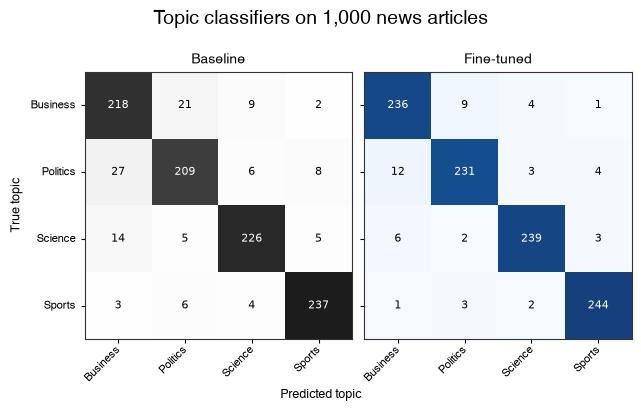

In [27]:
Heatmap(
    data=confusions,
    subtitle=["Baseline", "Fine-tuned"],
    style=[
        {"plot_heatmap_cmap": COLORS.Greys},
        {"plot_heatmap_cmap": COLORS.Blues},
    ],
    # the same value range for both charts, so the shades are comparable
    vmin=0,
    vmax=250,
    title="Topic classifiers on 1,000 news articles",
    xlabel="Predicted topic",
    ylabel="True topic",
    xticks=TOPIC_TICKS,
    xticklabels=TOPICS,
    xtickrotate=45,
    yticks=TOPIC_TICKS,
    yticklabels=TOPICS,
    figsize=(6.3, 4.0),
    aspect_ratio=ASPECT_RATIO.EQUAL,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.INTEGER,
    # label the true topics once
    sharey=True,
).show()